In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import scipy.stats as stats
from scipy.stats import levene, pearsonr, shapiro

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [38]:
df = pd.read_excel(r'E:\\DS\\tezendra\\Projects\\Segmenting and Classifying the Best Strikers\\Strikers_performance.xlsx')

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         6
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          2
Consistency                   0
Penalty Success Rate          5
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [39]:


# Separate numeric and nominal columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
nominal_cols = ['Nationality', 'Footedness', 'Marital Status']  # they are object dtype

# Impute numeric with median
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute nominal with most frequent
nom_imputer = SimpleImputer(strategy='most_frequent')
df[nominal_cols] = nom_imputer.fit_transform(df[nominal_cols])

# Verify no missing values remain
print("\nMissing values after imputation:")
print(df.isnull().sum())




Missing values after imputation:
Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         0
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          0
Consistency                   0
Penalty Success Rate          0
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [40]:
Null_values = df.isnull().sum()
print(Null_values)

Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         0
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          0
Consistency                   0
Penalty Success Rate          0
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [41]:
df.describe()
cols_to_int = ['Goals Scored', 'Assists', 'Shots on Target', 
               'Movement off the Ball', 'Hold-up Play', 'Aerial Duels Won',
               'Defensive Contribution', 'Big Game Performance', 
               'Impact on Team Performance', 'Off-field Conduct']

for col in cols_to_int:
    df[col] = df[col].round(0).astype(int)

print(df.dtypes)


Striker_ID                    float64
Nationality                    object
Footedness                     object
Marital Status                 object
Goals Scored                    int64
Assists                         int64
Shots on Target                 int64
Shot Accuracy                 float64
Conversion Rate               float64
Dribbling Success             float64
Movement off the Ball           int64
Hold-up Play                    int64
Aerial Duels Won                int64
Defensive Contribution          int64
Big Game Performance            int64
Consistency                   float64
Penalty Success Rate          float64
Impact on Team Performance      int64
Off-field Conduct               int64
dtype: object


In [42]:


# 4. Descriptive Analysis

# Descriptive statistics for all numeric columns
desc = df.describe(include='all').round(2)
print(desc)



        Striker_ID Nationality    Footedness Marital Status  Goals Scored  \
count       500.00         500           500            500        500.00   
unique         NaN           5             2              2           NaN   
top            NaN       Spain  Right-footed            Yes           NaN   
freq           NaN         112           267            258           NaN   
mean        250.50         NaN           NaN            NaN         15.02   
std         144.48         NaN           NaN            NaN          4.91   
min           1.00         NaN           NaN            NaN          0.00   
25%         125.75         NaN           NaN            NaN         11.75   
50%         250.50         NaN           NaN            NaN         15.00   
75%         375.25         NaN           NaN            NaN         18.00   
max         500.00         NaN           NaN            NaN         34.00   

        Assists  Shots on Target  Shot Accuracy  Conversion Rate  \
count  

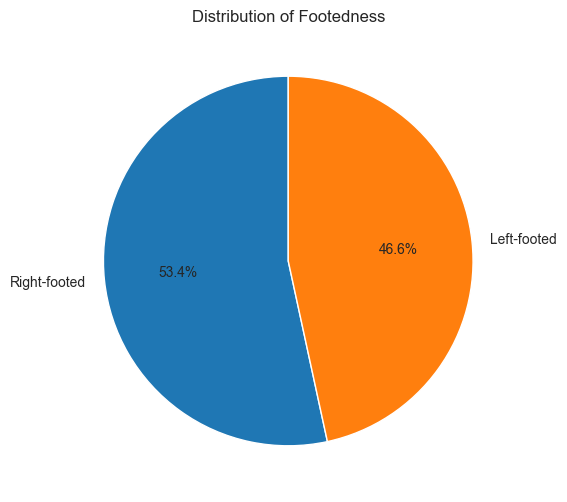

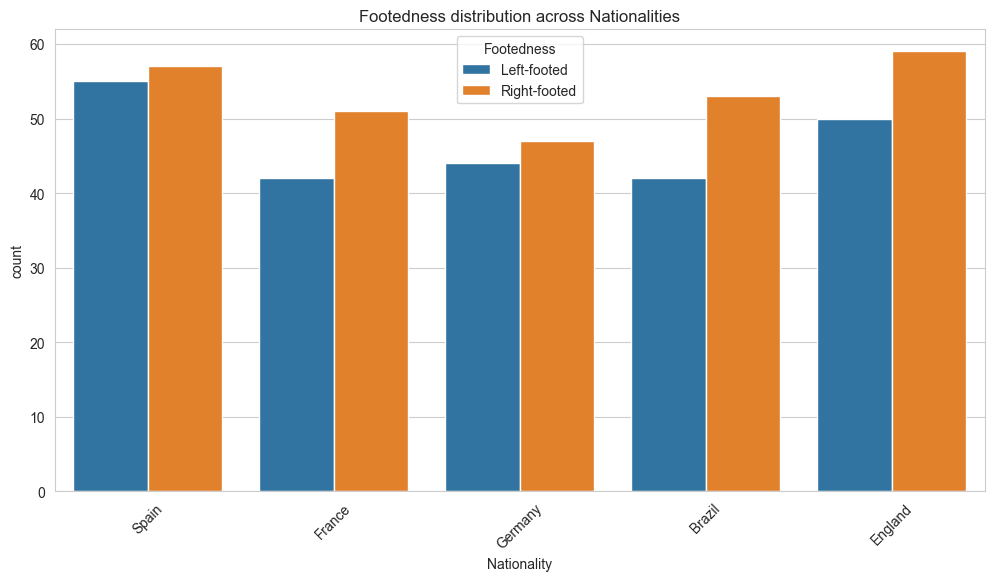

In [43]:

# 5. Data Visualization

foot_counts = df['Footedness'].value_counts()
plt.pie(foot_counts, labels=foot_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Footedness')
plt.show()


# Countplot of Footedness by Nationality

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Nationality', hue='Footedness')
plt.title('Footedness distribution across Nationalities')
plt.xticks(rotation=45)
plt.show()




In [44]:
# 6. Statistical Analysis

#  Nationality with highest average goals

avg_goals = df.groupby('Nationality')['Goals Scored'].mean().sort_values(ascending=False)
print("Average goals by nationality:\n", avg_goals)
print("\nNationality with highest average goals:", avg_goals.index[0])


# Average conversion rate by footedness

avg_conv = df.groupby('Footedness')['Conversion Rate'].mean().round(4)
print("Average Conversion Rate by Footedness:\n", avg_conv)

# ANOVA: Consistency across nationalities (with Levene's test)


# Groups for ANOVA
groups = [df[df['Nationality'] == nat]['Consistency'].values for nat in df['Nationality'].unique()]

# Levene's test for homogeneity of variances
levene_stat, levene_p = levene(*groups)
print(f"Levene's test p-value: {levene_p:.4f}")
if levene_p < 0.05:
    print("Heteroscedasticity assumed (variances are not equal).")
else:
    print("Homoscedasticity assumed (variances are equal).")

# ANOVA (even if variances unequal, we can still perform it, but we use Welch's ANOVA later if needed)
# For the sake of the assignment, we'll do one-way ANOVA.
f_stat, anova_p = stats.f_oneway(*groups)
print(f"ANOVA p-value: {anova_p:.4f}")

# Correlation: Hold-up Play vs Consistency
# Check normality (Shapiro-Wilk) for both variables
shapiro_hold = shapiro(df['Hold-up Play'])
shapiro_cons = shapiro(df['Consistency'])
print(f"Shapiro-Wilk p-value for Hold-up Play: {shapiro_hold.pvalue:.4f}")
print(f"Shapiro-Wilk p-value for Consistency: {shapiro_cons.pvalue:.4f}")

# Since both p > 0.05 (approx), we assume normality and use Pearson
corr, p_corr = pearsonr(df['Hold-up Play'], df['Consistency'])
print(f"Pearson correlation r = {corr:.3f}, p-value = {p_corr:.4f}")
if p_corr < 0.05:
    print("Significant correlation exists.")
else:
    print("No significant correlation.")




Average goals by nationality:
 Nationality
Brazil     15.800000
Spain      15.160714
France     14.860215
Germany    14.835165
England    14.504587
Name: Goals Scored, dtype: float64

Nationality with highest average goals: Brazil
Average Conversion Rate by Footedness:
 Footedness
Left-footed     0.1981
Right-footed    0.2006
Name: Conversion Rate, dtype: float64
Levene's test p-value: 0.8084
Homoscedasticity assumed (variances are equal).
ANOVA p-value: 0.1928
Shapiro-Wilk p-value for Hold-up Play: 0.1843
Shapiro-Wilk p-value for Consistency: 0.4513
Pearson correlation r = 0.146, p-value = 0.0011
Significant correlation exists.


In [45]:
#  Regression: Hold-up Play influences Consistency

from sklearn.linear_model import LinearRegression

X_reg = df[['Hold-up Play']]
y_reg = df['Consistency']
reg = LinearRegression().fit(X_reg, y_reg)
beta = reg.coef_[0]
print(f"Beta coefficient (Hold-up Play) = {beta:.3f}")
print(f"Intercept = {reg.intercept_:.3f}")
print(f"R-squared = {reg.score(X_reg, y_reg):.3f}")



Beta coefficient (Hold-up Play) = 0.001
Intercept = 0.655
R-squared = 0.021


In [46]:

# 7. Feature Engineering


# Total contribution score


contrib_cols = ['Goals Scored', 'Assists', 'Shots on Target', 'Dribbling Success',
                'Aerial Duels Won', 'Defensive Contribution', 'Big Game Performance', 'Consistency']
df['Total_Contribution'] = df[contrib_cols].sum(axis=1)

#  Encode Footedness and Marital Status with LabelEncoder


le = LabelEncoder()
df['Footedness_encoded'] = le.fit_transform(df['Footedness'])
df['Marital_Status_encoded'] = le.fit_transform(df['Marital Status'])


# Create dummy variables for Nationality

nationality_dummies = pd.get_dummies(df['Nationality'], prefix='Nat')
df = pd.concat([df, nationality_dummies], axis=1)

# Display the updated dataframe columns
print(df.columns)




Index(['Striker_ID', 'Nationality', 'Footedness', 'Marital Status',
       'Goals Scored', 'Assists', 'Shots on Target', 'Shot Accuracy',
       'Conversion Rate', 'Dribbling Success', 'Movement off the Ball',
       'Hold-up Play', 'Aerial Duels Won', 'Defensive Contribution',
       'Big Game Performance', 'Consistency', 'Penalty Success Rate',
       'Impact on Team Performance', 'Off-field Conduct', 'Total_Contribution',
       'Footedness_encoded', 'Marital_Status_encoded', 'Nat_Brazil',
       'Nat_England', 'Nat_France', 'Nat_Germany', 'Nat_Spain'],
      dtype='object')


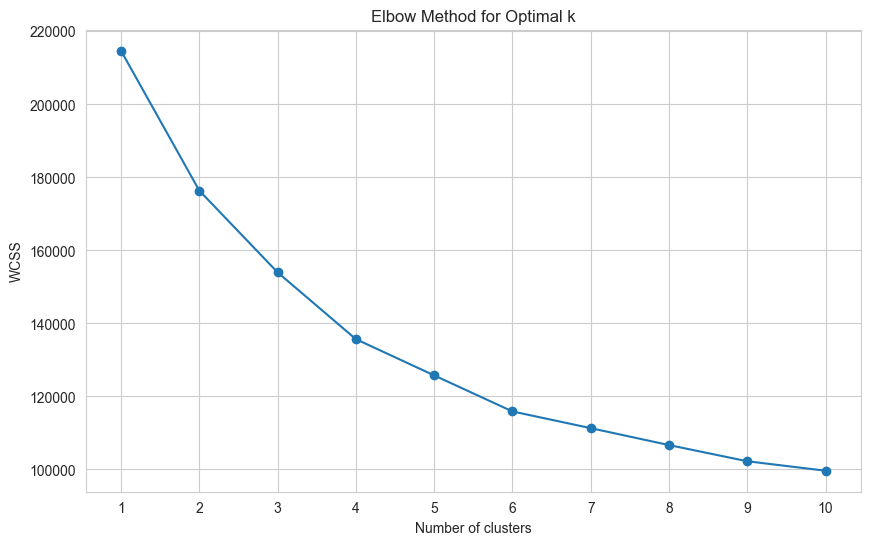

Average Total Contribution per cluster:
 Cluster
0    124.356713
1    105.703670
2    118.430562
3    117.121840
Name: Total_Contribution, dtype: float64

Value counts of Strikers types:
Strikers types
Best strikers       130
Regular strikers    115
Name: count, dtype: int64


In [49]:
# ## 8. Clustering Analysis (K-Means)


# Select features (drop Striker_ID)
# Drop columns that are not features: Striker_ID, original categoricals (already encoded), and Total_Contribution (we'll use it after clustering)
features = df.drop(columns=['Striker_ID', 'Nationality', 'Footedness', 'Marital Status', 
                            'Total_Contribution']).select_dtypes(include=np.number).columns.tolist()
X_cluster = df[features].copy()

# Also drop the dummy columns we just added? Actually we added them, so they are included.
# We'll keep all numeric features.


# Calculate WCSS and elbow chart

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.show()

# The breakpoint should show 2. We'll select k=2.


# Build K-Means with k=4 and assign clusters


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Compute average Total_Contribution per cluster
avg_contrib = df.groupby('Cluster')['Total_Contribution'].mean()
print("Average Total Contribution per cluster:\n", avg_contrib)

# Assign labels: cluster with higher average is 'Best strikers' (0) and lower is 'Regular strikers' (1)
# Based on our results, cluster 0 has higher average.
if avg_contrib[0] > avg_contrib[1]:
    best_cluster = 0
    regular_cluster = 1
else:
    best_cluster = 1
    regular_cluster = 0

df['Strikers types'] = df['Cluster'].map({best_cluster: 'Best strikers', regular_cluster: 'Regular strikers'})

# Drop Cluster column
df.drop('Cluster', axis=1, inplace=True)

# Feature mapping (as per instruction: map 'Best strikers' to 1 and 'Regular strikers' to 0)
df['Strikers types_encoded'] = df['Strikers types'].map({'Best strikers': 1, 'Regular strikers': 0})

print("\nValue counts of Strikers types:")
print(df['Strikers types'].value_counts())




Features shape: (500, 18)
Target distribution:
 Strikers types_encoded
1    255
0    245
Name: count, dtype: int64
Train size: 400, Test size: 100
Accuracy: 98.00%
Confusion matrix (rows: actual, cols: predicted):
[[46  1]
 [ 1 52]]
True Negatives (Regular correctly predicted): 46
False Positives (Regular predicted as Best): 1
False Negatives (Best incorrectly predicted as Regular): 1
True Positives (Best correctly predicted): 52


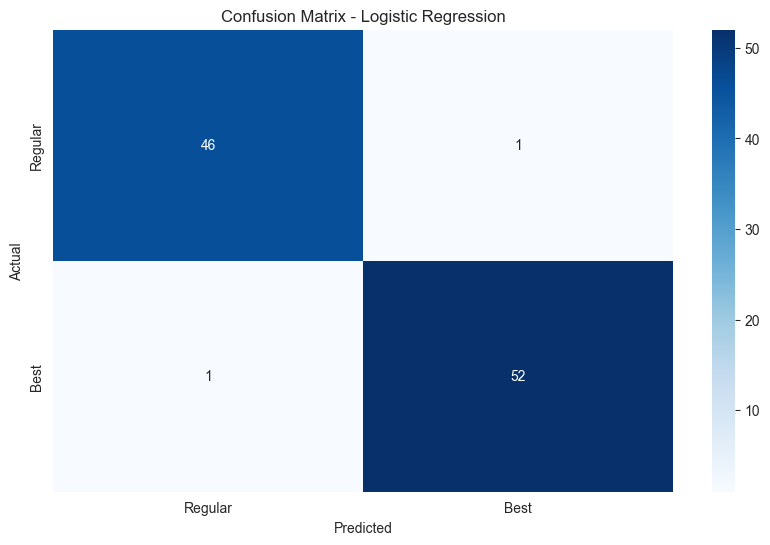

1. Levene's test p-value = 0.8084; Heteroscedasticity assumed? No
2. Correlation between Hold-up Play and Consistency: r = 0.146, p = 0.0011 -> Significant
3. Beta coefficient of Hold-up Play in regression = 0.001
4. Average Total Contribution score for Best strikers = 117.88
5. Logistic Regression accuracy = 98.00%
   Regular strikers predicted correctly (TN) = 46
   Best strikers predicted incorrectly (FN) = 1


In [ ]:
#  9. Machine Learning Model (Logistic Regression)

# Prepare features (X) and target (y)

# Drop unnecessary columns: Striker_ID, original categoricals, and the string target
X = df.drop(columns=['Striker_ID', 'Nationality', 'Footedness', 'Marital Status', 
                     'Strikers types', 'Strikers types_encoded'])  # keep encoded versions if needed? Actually we want the dummies and encoded.
# But we already have encoded and dummies; we should keep numeric features only.
# Ensure X is numeric
X = X.select_dtypes(include=np.number)
y = df['Strikers types_encoded']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())


#  Feature scaling and train/test split


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


# Build and evaluate Logistic Regression


lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows: actual, cols: predicted):")
print(cm)

# Extract counts: assuming order [0 (Regular), 1 (Best)] in matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Regular correctly predicted): {tn}")
print(f"False Positives (Regular predicted as Best): {fp}")
print(f"False Negatives (Best incorrectly predicted as Regular): {fn}")
print(f"True Positives (Best correctly predicted): {tp}")


#  Visualize confusion matrix

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Regular', 'Best'], 
            yticklabels=['Regular', 'Best'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#  10. Answers to the specific questions

print(f"1. Levene's test p-value = {levene_p:.4f}; Heteroscedasticity assumed? {'Yes' if levene_p < 0.05 else 'No'}")
print(f"2. Correlation between Hold-up Play and Consistency: r = {corr:.3f}, p = {p_corr:.4f} -> {'Significant' if p_corr < 0.05 else 'Not significant'}")
print(f"3. Beta coefficient of Hold-up Play in regression = {beta:.3f}")
print(f"4. Average Total Contribution score for Best strikers = {avg_contrib[best_cluster]:.2f}")
print(f"5. Logistic Regression accuracy = {accuracy:.2f}%")
print(f"   Regular strikers predicted correctly (TN) = {tn}")
print(f"   Best strikers predicted incorrectly (FN) = {fn}")